<a href="https://colab.research.google.com/github/code-pyro1/code-pyro1/blob/main/VibeCodedClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Overview:
Shape: (768, 9)

First few rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non

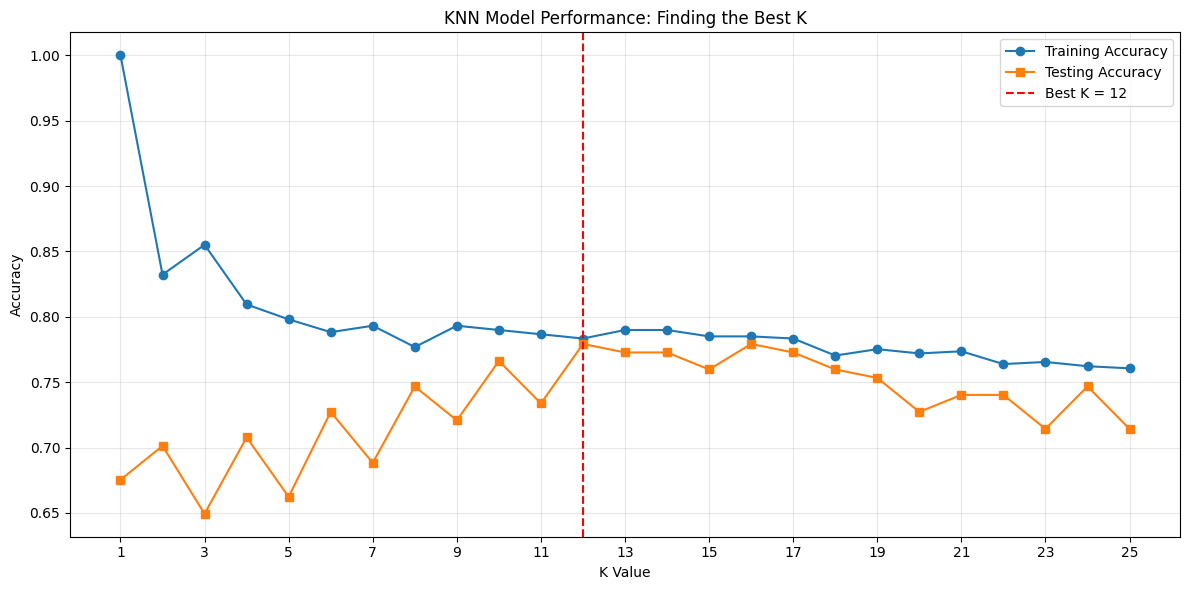


Final Model Evaluation (K=12)
Accuracy: 0.7792

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        99
           1       0.76      0.56      0.65        55

    accuracy                           0.78       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.78      0.78      0.77       154



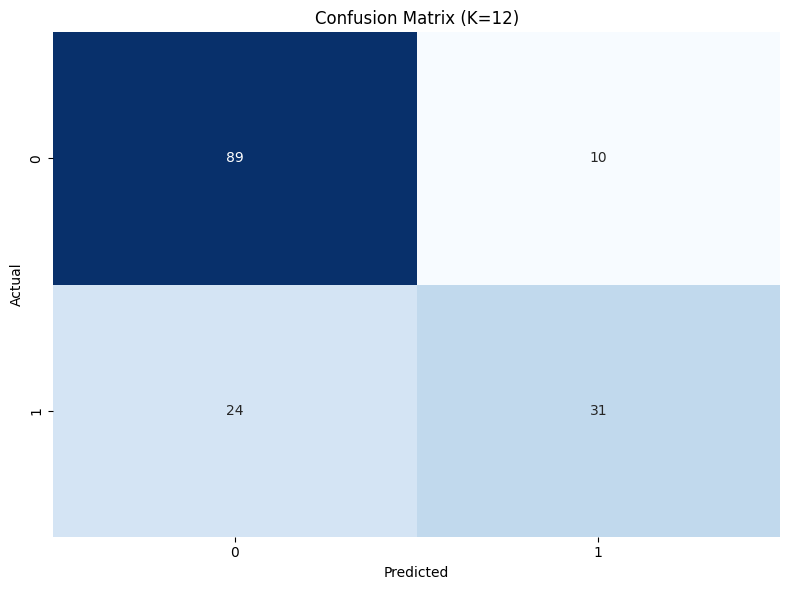


PREDICTION MODE - Enter Patient Data

Do you want to make a prediction for a patient? (yes/no): yes

Please enter values for the following features:
(Note: These should match your diabetes dataset features)
Enter Pregnancies: 6
Enter Glucose: 148
Enter BloodPressure: 72
Enter SkinThickness: 35
Enter Insulin: 100
Enter BMI: 34
Enter DiabetesPedigreeFunction: 0.5
Enter Age: 35


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(



PREDICTION RESULT
Prediction: Diabetic (1)
Probability - Non-Diabetic: 0.3333
Probability - Diabetic: 0.6667

Do you want to make another prediction? (yes/no): no
Program completed!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Load the data
data_path = r"/content/sample_data/diabetes.csv"
df = pd.read_csv(data_path)

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:\n{df.head()}")
print(f"\nDataset Info:\n{df.info()}")
print(f"\nBasic Statistics:\n{df.describe()}")

# Prepare the data
X = df.drop('Outcome', axis=1)  # Features (adjust 'Outcome' if column name is different)
y = df['Outcome']  # Target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Find the best K value
k_values = range(1, 26)
train_accuracies = []
test_accuracies = []

print("\nTraining models for K values 1-25...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Find the best K
best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)

print(f"\nBest K: {best_k}")
print(f"Best Test Accuracy: {best_accuracy:.4f}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Testing Accuracy', marker='s')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Model Performance: Finding the Best K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 26, 2))
plt.tight_layout()
plt.show()

# Train the final model with best K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

# Evaluate on test set
y_pred = final_knn.predict(X_test)
print(f"\n{'='*50}")
print(f"Final Model Evaluation (K={best_k})")
print(f"{'='*50}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

# User Input Section
print(f"\n{'='*50}")
print("PREDICTION MODE - Enter Patient Data")
print(f"{'='*50}")

def get_user_prediction():
    """Get user input for prediction"""
    try:
        # Get feature names from the dataset (excluding Outcome)
        feature_names = list(X.columns)

        print(f"\nPlease enter values for the following features:")
        print("(Note: These should match your diabetes dataset features)")

        user_input = []
        for feature in feature_names:
            while True:
                try:
                    value = float(input(f"Enter {feature}: "))
                    user_input.append(value)
                    break
                except ValueError:
                    print(f"Invalid input. Please enter a numeric value for {feature}.")

        # Make prediction
        user_array = np.array(user_input).reshape(1, -1)
        prediction = final_knn.predict(user_array)[0]
        probability = final_knn.predict_proba(user_array)[0]

        print(f"\n{'='*50}")
        print("PREDICTION RESULT")
        print(f"{'='*50}")
        print(f"Prediction: {'Diabetic (1)' if prediction == 1 else 'Non-Diabetic (0)'}")
        print(f"Probability - Non-Diabetic: {probability[0]:.4f}")
        print(f"Probability - Diabetic: {probability[1]:.4f}")
        print(f"{'='*50}\n")

        # Ask if user wants to make another prediction
        another = input("Do you want to make another prediction? (yes/no): ").lower()
        if another in ['yes', 'y']:
            get_user_prediction()

    except Exception as e:
        print(f"Error: {e}")

# Run the prediction mode
make_prediction = input("\nDo you want to make a prediction for a patient? (yes/no): ").lower()
if make_prediction in ['yes', 'y']:
    get_user_prediction()

print("Program completed!")
